# Milos — farmer WSP + replan Gantt

Self-contained under `milos/` (no `agent/`). Primary plots are **farmer-only** (5 tiles).

Optional: smoke `[wsp_plan]` lines from the live agent are filtered to zone I (`t1`–`t5`) so you can compare day-0 / replan for the farmer snake only — not full TwoLand.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "main.py").exists() and not (ROOT / "milos").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

%matplotlib inline

from milos import (
    FARMER_TILES,
    board_for_plot,
    build_day0,
    empty_board,
    merge_wsp_plan,
)
from milos.wsp import load_wsp_plans, plot_plan, plot_zone_ops_replans
from milos.wsp.plan_actions import plot_planner_board_actions

SMOKE_LOG = ROOT / "scripts/smoke.txt"
print(SMOKE_LOG, SMOKE_LOG.exists())


[zoning] CURRENT=milos_farmer tiles=5 hands=0
/media/wlaki/W/DS_projects/Kaggle/kaggriculture/scripts/smoke.txt True


## Farmer-only WSP (`milos.planner.build_day0`)

Day-0 calls `milos.wsp.farmer.solve`, then planner writes an **absolute** tile board for Gantt.


[milos/wsp] farmer prestart zone I tiles=[0, 1, 2, 3, 4] from prestart.json (full=25) complete=True
complete True tiles [0, 1, 2, 3, 4]


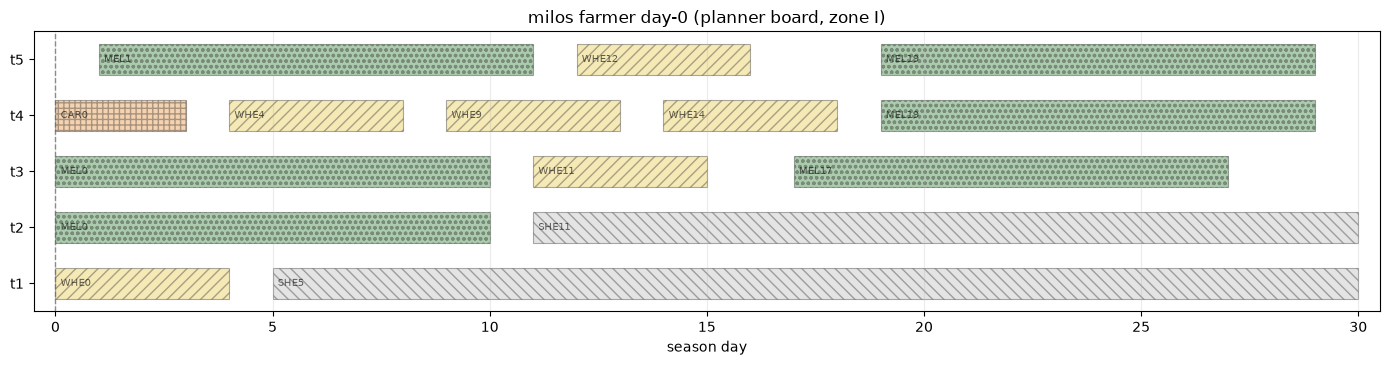

In [3]:
board, result = build_day0(starting_money=3000)
print("complete", result.complete, "tiles", sorted(board))
plot_plan(
    board_for_plot(board),
    replan_day=0,
    horizon=30,
    absolute=True,
    title="milos farmer day-0 (planner board, zone I)",
)


## Smoke log — full farmer Gantt per replan

Merge each `[wsp_plan]` via `milos.planner.merge_wsp_plan`, then plot the **full** zone-I board: past α=0.3, unchanged future α=0.6, **this replan's tiles α=1.0**.


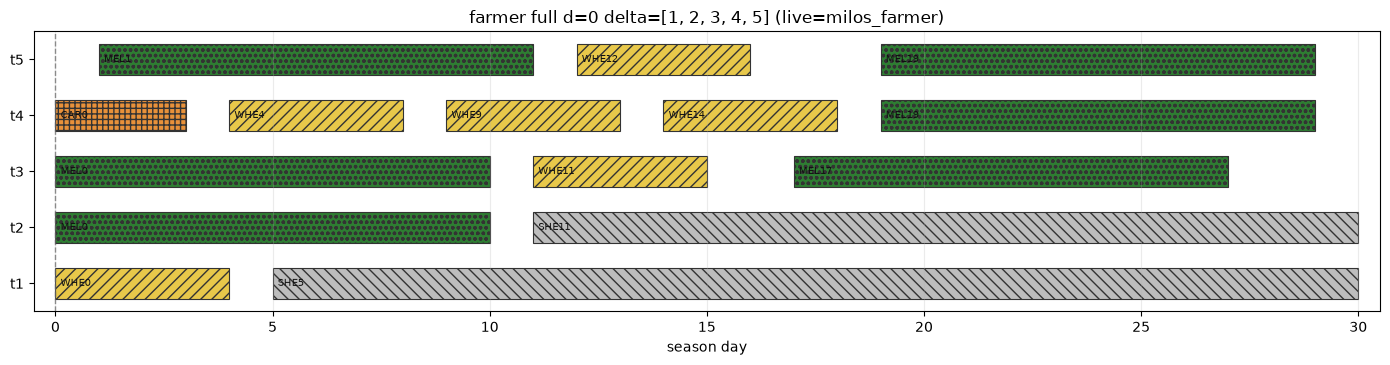

plotted 1/1 events (skipped empty farmer deltas)


In [4]:
farmer_set = set(FARMER_TILES)
plans = load_wsp_plans(SMOKE_LOG) if SMOKE_LOG.exists() else []
board = empty_board()
plotted = 0
for plan in plans:
    delta = merge_wsp_plan(board, plan, tiles=farmer_set)
    if not delta:
        continue
    plotted += 1
    plot_plan(
        board_for_plot(board),
        replan_day=plan.day,
        horizon=plan.horizon,
        now=plan.day,
        absolute=True,
        delta_tiles=delta,
        title=f"farmer full d={plan.day} delta={sorted(t+1 for t in delta)} (live={plan.solver})",
    )
print(f"plotted {plotted}/{len(plans)} events (skipped empty farmer deltas)")


## Farmer OPS by replan

Same smoke `[wsp_plan]` stream as the Gantt (live **TwoLand** agent), but **farmer / zone I only** (`t1`–`t5`). One **line + dots** per replan: total planned `daily_tile_ops` from that replan day to season end. Color = replan index (`turbo`; colorbar = replan day).


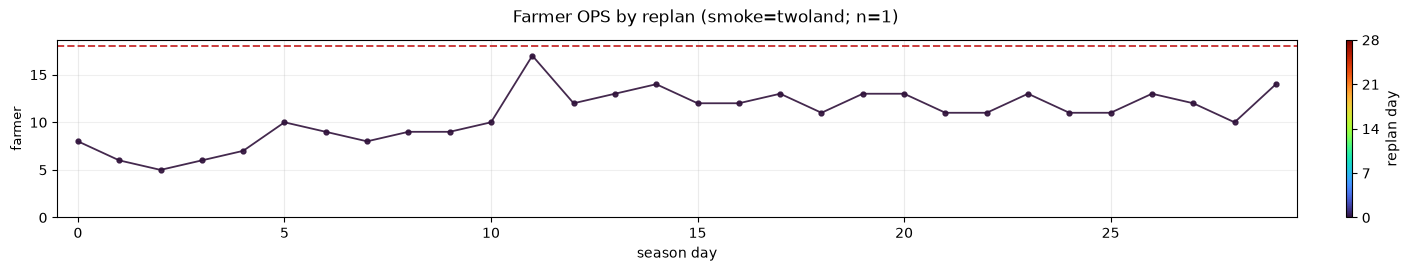

In [5]:
farmer_set = set(FARMER_TILES)
plans_farmer = load_wsp_plans(SMOKE_LOG) if SMOKE_LOG.exists() else []
plot_zone_ops_replans(
    plans_farmer,
    {"farmer": farmer_set},
    title=f"Farmer OPS by replan (smoke=twoland; n={len(plans_farmer)})",
)

## Farmer planned actions by replan

Same merged planner board as the Gantt section, shown as a **worker×action heatmap** (like `smoke_analysis.plot_worker_actions`): rollout tape stamped on the farmer snake, one figure per replan with a farmer delta.


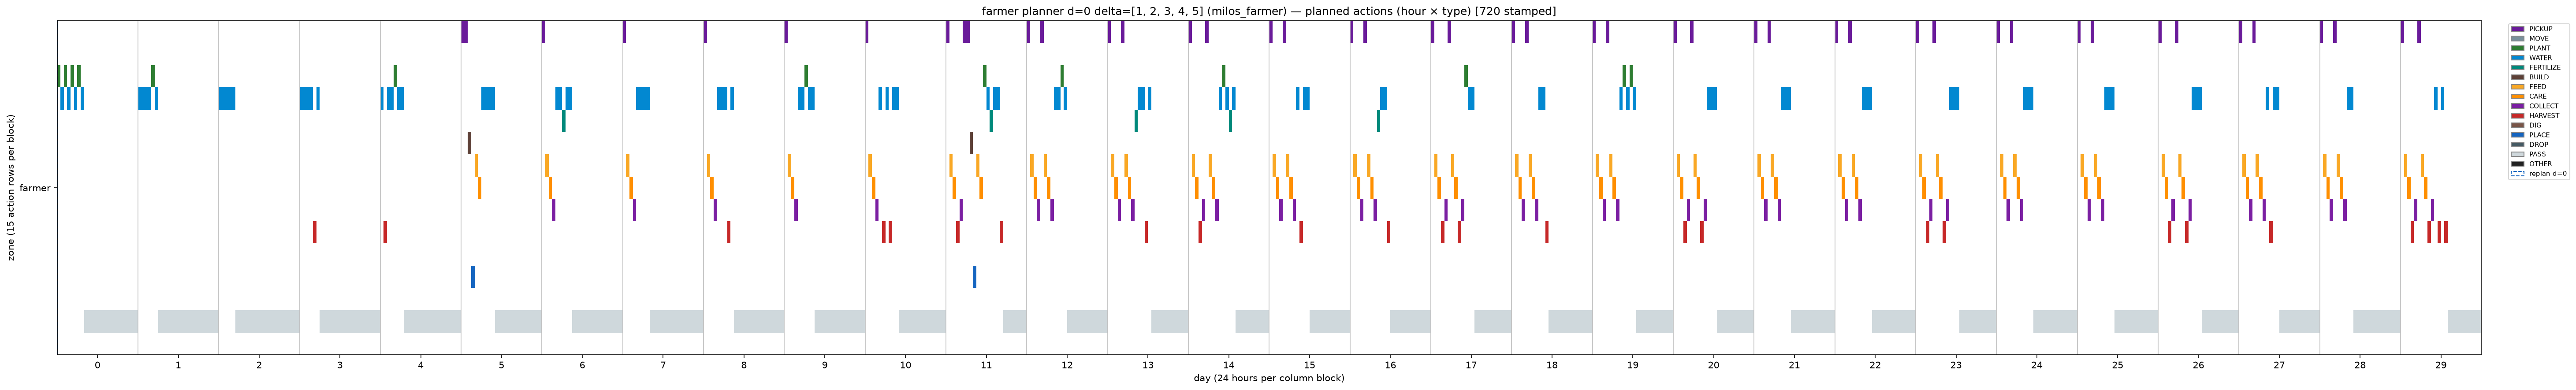

plotted 1/1 planned-action heatmaps


In [6]:
farmer_set = set(FARMER_TILES)
plans = load_wsp_plans(SMOKE_LOG) if SMOKE_LOG.exists() else []
board = empty_board()
plotted = 0
for plan in plans:
    delta = merge_wsp_plan(board, plan, tiles=farmer_set)
    if not delta:
        continue
    plotted += 1
    plot_planner_board_actions(
        board_for_plot(board),
        replan_day=plan.day,
        title=f"farmer planner d={plan.day} delta={sorted(t+1 for t in delta)} ({plan.solver})",
    )
print(f"plotted {plotted}/{len(plans)} planned-action heatmaps")


## Planner → executor I/O (initial plan only)

**INPUT** — what the planner installs: `milos.script.TILE_QUEUES` (`QueueItem` rows per tile), plus optional raw WSP chains from `build_day0()`.

**OUTPUT** — what the executor returns each hour: `farmer` / `market` from a live 720-step run (`milos.executor.step`), not the synthetic `board_planned_events` tape used for heatmaps.

Run the day-0 cell above first (same kernel). Set `MAX_DAYS = N` to limit printed days; default is full season (30 days).

In [7]:
from milos.diagnostics import (
    planner_queue_rows,
    print_planner_executor_trace,
    wsp_chain_rows,
)
from milos.script import TILE_QUEUES

# Reuse `board, result` from build_day0 above; queues match script.TILE_QUEUES at import.
MAX_DAYS = None  # int e.g. 3 to truncate; None = all 30 days
DAY_RANGE = range(MAX_DAYS) if MAX_DAYS is not None else None

_episode_rows = print_planner_executor_trace(
    tile_queues=TILE_QUEUES,
    wsp_rows=wsp_chain_rows(result),
    days=DAY_RANGE,
    show_pass=False,
    run_episode=True,
)

# DataFrame-friendly tables (optional)
try:
    import pandas as pd

    display(pd.DataFrame(planner_queue_rows(TILE_QUEUES)))
except ImportError:
    pass

[milos/wsp] farmer prestart zone I tiles=[0, 1, 2, 3, 4] from prestart.json (full=25) complete=True
=== PLANNER → EXECUTOR INPUT (day-0 TILE_QUEUES) ===
tile | qi | kind   | label      | profile   | start_lag | replant_gap | dig_before
t1  | 0  | crop   | WHEAT      | no_fert   |         0 |           1 | False
t1  | 1  | animal | SHEEP      | with_care |         0 |           0 | False
t2  | 0  | crop   | MELON      | no_fert   |         0 |           1 | False
t2  | 1  | animal | SHEEP      | with_care |         0 |           0 | False
t3  | 0  | crop   | MELON      | no_fert   |         0 |           1 | False
t3  | 1  | crop   | WHEAT      | with_fert |         0 |           2 | False
t3  | 2  | crop   | MELON      | no_fert   |         0 |           0 | False
t4  | 0  | crop   | CARROT     | no_fert   |         0 |           1 | False
t4  | 1  | crop   | WHEAT      | with_fert |         0 |           1 | False
t4  | 2  | crop   | WHEAT      | with_fert |         0 |           1 | 

,tile,qi,kind,label,profile,start_lag,replant_gap,dig_before
0,0,0,crop,WHEAT,no_fert,0,1,False
1,0,1,animal,SHEEP,with_care,0,0,False
2,1,0,crop,MELON,no_fert,0,1,False
3,1,1,animal,SHEEP,with_care,0,0,False
4,2,0,crop,MELON,no_fert,0,1,False
5,2,1,crop,WHEAT,with_fert,0,2,False
6,2,2,crop,MELON,no_fert,0,0,False
7,3,0,crop,CARROT,no_fert,0,1,False
8,3,1,crop,WHEAT,with_fert,0,1,False
9,3,2,crop,WHEAT,with_fert,0,1,False
